# 高齢化率と医療費の関係分析  
― 都道府県別データを用いた基礎分析 ―

高齢化率と医療費の関係について

## 背景

日本では高齢化が進行しており、医療費の増大が社会的課題となっている。  
特に、高齢化率の上昇が医療費にどの程度影響を与えているのかを定量的に把握することは、地域医療や社会保障制度を検討する上で重要である。

## 目的

本分析では、都道府県別の人口・高齢者人口・医療費データを用いて、

・高齢化率と医療費の関係を可視化する  
・相関関係を数値的に評価する  
・医療費の地域差をランキングで確認する  

ことを目的とする。

##使用データ
本分析では以下のデータを使用した。

・総務省統計局　令和2年国勢調査

・厚生労働省　令和2年度国民医療費の概況

これらのデータを都道府県名で結合し、分析用データセットを作成した。

In [95]:
#2020年国勢調査人口統計データ確認
import pandas as pd
df = pd.read_excel("人口統計(2020).xlsx", skiprows = 8)
df.columns = df.iloc[1]
df.head()

1,国籍総数か日本人,男女,地域識別コード,地域名,,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,人,人,人,人,人,人,...,人,人,人,人,人,人,人,人,歳,歳
1,国籍総数か日本人,男女,地域識別コード,地域名,,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0_国籍総数,0_総数,a,00000_全国,126146099,831824,866525,910005,934063,973665,...,2931838,14955692,72922764,35335805,18248742,6021086,79523,75380592,47.66094,48.60554
3,0_国籍総数,0_総数,a,01000_北海道,5224614,29612,31000,32661,33672,35428,...,59060,555804,2945727,1664023,848273,292909,3892,3120373,49.80523,51.40664
4,0_国籍総数,0_総数,1,01100_札幌市,1973395,12220,12616,13160,13466,14130,...,31063,215366,1185724,541242,264920,90743,1145,1235758,47.72261,48.54738


In [96]:
df.tail()

1,国籍総数か日本人,男女,地域識別コード,地域名,,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
591,1_うち日本人,2_女,a,44000_大分県,577579,3555,3673,3956,4004,4300,...,2920,65855,295879,212925,120436,49875,875,316810,51.93529,54.66567
592,1_うち日本人,2_女,a,45000_宮崎県,554077,3717,3848,4009,4221,4335,...,739,68231,286882,198225,110456,46759,916,307223,51.21583,53.89043
593,1_うち日本人,2_女,a,46000_鹿児島県,817684,5364,5709,6112,6094,6458,...,5149,99517,423948,289070,164385,72509,1475,454236,51.28558,54.12113
594,1_うち日本人,2_女,2,46201_鹿児島市,302548,2062,2102,2304,2229,2393,...,4170,36499,170382,91497,48820,20051,367,178291,48.80342,50.10599
595,1_うち日本人,2_女,a,47000_沖縄県,725378,7161,7123,7502,7650,7956,...,1711,118415,427167,178085,93378,38125,1034,436417,44.62179,45.11837


In [97]:
import pandas as pd

# 読み込み（列名なし）
df_raw = pd.read_excel(
    "人口統計(2020).xlsx",
    skiprows=8,
    header=None
)

# 上段（年齢など）
upper = df_raw.iloc[0]

# 下段（国籍など）
lower = df_raw.iloc[2]

# 列名作成
cols = []

for u, l in zip(upper, lower):

    if pd.notna(l):
        cols.append(l)

    elif pd.notna(u):
        cols.append(u)

    else:
        cols.append("")

# 列名セット
df_raw.columns = cols

# 不要行削除（0,1,2行）
df = df_raw.drop([0,1,2]).reset_index(drop=True)

df.head()

,国籍総数か日本人,男女,地域識別コード,地域名,,001_0歳,002_1歳,003_2歳,004_3歳,005_4歳,...,112_年齢「不詳」,R1_（再掲）15歳未満,R2_（再掲）15～64歳,R3_（再掲）65歳以上,R4_（再掲）75歳以上,R5_（再掲）85歳以上,R6_（再掲）100歳以上,R7_（再掲）20～69歳,,
0,0_国籍総数,0_総数,a,00000_全国,126146099,831824,866525,910005,934063,973665,...,2931838,14955692,72922764,35335805,18248742,6021086,79523,75380592,47.66094,48.60554
1,0_国籍総数,0_総数,a,01000_北海道,5224614,29612,31000,32661,33672,35428,...,59060,555804,2945727,1664023,848273,292909,3892,3120373,49.80523,51.40664
2,0_国籍総数,0_総数,1,01100_札幌市,1973395,12220,12616,13160,13466,14130,...,31063,215366,1185724,541242,264920,90743,1145,1235758,47.72261,48.54738
3,0_国籍総数,0_総数,a,02000_青森県,1237984,6658,6983,7526,7813,8354,...,19762,129112,676167,412943,210338,73743,714,724776,50.89684,53.47269
4,0_国籍総数,0_総数,a,03000_岩手県,1210534,6555,7064,7453,8023,8249,...,14912,132447,658816,404359,214277,79615,927,702418,50.6744,53.01862


In [98]:
df = df.rename(columns={" ": "総人口"})

df.columns[:15]

Index(['国籍総数か日本人', '男女', '地域識別コード', '地域名', '総人口', '001_0歳', '002_1歳', '003_2歳',
       '004_3歳', '005_4歳', '006_5歳', '007_6歳', '008_7歳', '009_8歳', '010_9歳'],
      dtype='object')

In [99]:
df.head()

,国籍総数か日本人,男女,地域識別コード,地域名,総人口,001_0歳,002_1歳,003_2歳,004_3歳,005_4歳,...,112_年齢「不詳」,R1_（再掲）15歳未満,R2_（再掲）15～64歳,R3_（再掲）65歳以上,R4_（再掲）75歳以上,R5_（再掲）85歳以上,R6_（再掲）100歳以上,R7_（再掲）20～69歳,,
0,0_国籍総数,0_総数,a,00000_全国,126146099,831824,866525,910005,934063,973665,...,2931838,14955692,72922764,35335805,18248742,6021086,79523,75380592,47.66094,48.60554
1,0_国籍総数,0_総数,a,01000_北海道,5224614,29612,31000,32661,33672,35428,...,59060,555804,2945727,1664023,848273,292909,3892,3120373,49.80523,51.40664
2,0_国籍総数,0_総数,1,01100_札幌市,1973395,12220,12616,13160,13466,14130,...,31063,215366,1185724,541242,264920,90743,1145,1235758,47.72261,48.54738
3,0_国籍総数,0_総数,a,02000_青森県,1237984,6658,6983,7526,7813,8354,...,19762,129112,676167,412943,210338,73743,714,724776,50.89684,53.47269
4,0_国籍総数,0_総数,a,03000_岩手県,1210534,6555,7064,7453,8023,8249,...,14912,132447,658816,404359,214277,79615,927,702418,50.6744,53.01862


In [100]:
# 地域名を、地域コードと地域名_新に分割

df[["地域コード", "地域名_新"]] = df["地域名"].str.split("_", expand=True)

df.head()

,国籍総数か日本人,男女,地域識別コード,地域名,総人口,001_0歳,002_1歳,003_2歳,004_3歳,005_4歳,...,R2_（再掲）15～64歳,R3_（再掲）65歳以上,R4_（再掲）75歳以上,R5_（再掲）85歳以上,R6_（再掲）100歳以上,R7_（再掲）20～69歳,,,地域コード,地域名_新
0,0_国籍総数,0_総数,a,00000_全国,126146099,831824,866525,910005,934063,973665,...,72922764,35335805,18248742,6021086,79523,75380592,47.66094,48.60554,00000,全国
1,0_国籍総数,0_総数,a,01000_北海道,5224614,29612,31000,32661,33672,35428,...,2945727,1664023,848273,292909,3892,3120373,49.80523,51.40664,01000,北海道
2,0_国籍総数,0_総数,1,01100_札幌市,1973395,12220,12616,13160,13466,14130,...,1185724,541242,264920,90743,1145,1235758,47.72261,48.54738,01100,札幌市
3,0_国籍総数,0_総数,a,02000_青森県,1237984,6658,6983,7526,7813,8354,...,676167,412943,210338,73743,714,724776,50.89684,53.47269,02000,青森県
4,0_国籍総数,0_総数,a,03000_岩手県,1210534,6555,7064,7453,8023,8249,...,658816,404359,214277,79615,927,702418,50.6744,53.01862,03000,岩手県


人口データの整理、不要行の削除、列名の調整などを行う。

In [101]:
#"国籍総数か日本人"には、総数以外に日本人だけも含まれるため、総数を抽出。
#"男女"には、男のみ、女のみも含まれるため、男女の総数を抽出。

df = df[
    (df["国籍総数か日本人"] == "0_国籍総数") &
    (df["男女"] == "0_総数")
]

df.head()

,国籍総数か日本人,男女,地域識別コード,地域名,総人口,001_0歳,002_1歳,003_2歳,004_3歳,005_4歳,...,R2_（再掲）15～64歳,R3_（再掲）65歳以上,R4_（再掲）75歳以上,R5_（再掲）85歳以上,R6_（再掲）100歳以上,R7_（再掲）20～69歳,,,地域コード,地域名_新
0,0_国籍総数,0_総数,a,00000_全国,126146099,831824,866525,910005,934063,973665,...,72922764,35335805,18248742,6021086,79523,75380592,47.66094,48.60554,00000,全国
1,0_国籍総数,0_総数,a,01000_北海道,5224614,29612,31000,32661,33672,35428,...,2945727,1664023,848273,292909,3892,3120373,49.80523,51.40664,01000,北海道
2,0_国籍総数,0_総数,1,01100_札幌市,1973395,12220,12616,13160,13466,14130,...,1185724,541242,264920,90743,1145,1235758,47.72261,48.54738,01100,札幌市
3,0_国籍総数,0_総数,a,02000_青森県,1237984,6658,6983,7526,7813,8354,...,676167,412943,210338,73743,714,724776,50.89684,53.47269,02000,青森県
4,0_国籍総数,0_総数,a,03000_岩手県,1210534,6555,7064,7453,8023,8249,...,658816,404359,214277,79615,927,702418,50.6744,53.01862,03000,岩手県


In [102]:
#データ型の確認
df.dtypes.head(10)

,0
国籍総数か日本人,object
男女,object
地域識別コード,object
地域名,object
総人口,object
001_0歳,object
002_1歳,object
003_2歳,object
004_3歳,object
005_4歳,object


In [103]:
#欠損値確認
df[["総人口", "R3_（再掲）65歳以上"]].isnull().sum()

,0
総人口,0
R3_（再掲）65歳以上,0


In [104]:
df.head()

,国籍総数か日本人,男女,地域識別コード,地域名,総人口,001_0歳,002_1歳,003_2歳,004_3歳,005_4歳,...,R2_（再掲）15～64歳,R3_（再掲）65歳以上,R4_（再掲）75歳以上,R5_（再掲）85歳以上,R6_（再掲）100歳以上,R7_（再掲）20～69歳,,,地域コード,地域名_新
0,0_国籍総数,0_総数,a,00000_全国,126146099,831824,866525,910005,934063,973665,...,72922764,35335805,18248742,6021086,79523,75380592,47.66094,48.60554,00000,全国
1,0_国籍総数,0_総数,a,01000_北海道,5224614,29612,31000,32661,33672,35428,...,2945727,1664023,848273,292909,3892,3120373,49.80523,51.40664,01000,北海道
2,0_国籍総数,0_総数,1,01100_札幌市,1973395,12220,12616,13160,13466,14130,...,1185724,541242,264920,90743,1145,1235758,47.72261,48.54738,01100,札幌市
3,0_国籍総数,0_総数,a,02000_青森県,1237984,6658,6983,7526,7813,8354,...,676167,412943,210338,73743,714,724776,50.89684,53.47269,02000,青森県
4,0_国籍総数,0_総数,a,03000_岩手県,1210534,6555,7064,7453,8023,8249,...,658816,404359,214277,79615,927,702418,50.6744,53.01862,03000,岩手県


## 高齢化率の計算

65歳以上人口を総人口で割り、高齢化率を算出する。

In [105]:
#必要な列だけを取り出し、新しいdfを作成
df["高齢化率(%)"] = (
    df["R3_（再掲）65歳以上"]
    / df["総人口"]
)

df_pref = df[["地域名_新", "総人口", "R3_（再掲）65歳以上", "高齢化率(%)"]]
df_pref.head()

,地域名_新,総人口,R3_（再掲）65歳以上,高齢化率(%)
0,全国,126146099,35335805,0.280118
1,北海道,5224614,1664023,0.318497
2,札幌市,1973395,541242,0.274269
3,青森県,1237984,412943,0.333561
4,岩手県,1210534,404359,0.334034


In [106]:
# 列名を揃える
df_pref = df_pref.rename(
    columns={"地域名_新": "都道府県",
             "R3_（再掲）65歳以上": "65歳以上人口"}
)

df_pref.head()

,都道府県,総人口,65歳以上人口,高齢化率(%)
0,全国,126146099,35335805,0.280118
1,北海道,5224614,1664023,0.318497
2,札幌市,1973395,541242,0.274269
3,青森県,1237984,412943,0.333561
4,岩手県,1210534,404359,0.334034


In [107]:
#高齢化率を百分率表示に変更
df_pref["高齢化率(%)"] = (
    df_pref["高齢化率(%)"] * 100
).round(1)

df_pref.head()

,都道府県,総人口,65歳以上人口,高齢化率(%)
0,全国,126146099,35335805,28.01181
1,北海道,5224614,1664023,31.849683
2,札幌市,1973395,541242,27.426947
3,青森県,1237984,412943,33.356085
4,岩手県,1210534,404359,33.403358


In [108]:
df_pref.sort_values("高齢化率(%)", ascending=False)

,都道府県,総人口,65歳以上人口,高齢化率(%)
7,秋田県,959502,357568,37.265998
86,高知県,691527,241787,34.964217
81,山口県,1342059,459957,34.272487
76,島根県,671126,227881,33.955025
8,山形県,1068027,359554,33.665254
...,...,...,...,...
26,文京区,240069,42020,17.503301
34,渋谷区,243883,41261,16.918358
24,港区,260486,42546,16.333315
22,千代田区,66680,10852,16.274745


In [109]:
#2020年一人当たり医療費確認
file = pd.ExcelFile("一人当たり医療費統計表(2020).xlsx")

file.sheet_names

['第1表',
 '第2表',
 '第3表',
 '第4表',
 '第5表（総数）',
 '第5表（男）',
 '第5表（女）',
 '第6表（総数）',
 '第6表（男）',
 '第6表（女）',
 '第7表',
 '参考１',
 '参考２ ']

In [110]:
#Excelファイルの"第7表"に全国データがあるので確認
df_med = pd.read_excel(
    "一人当たり医療費統計表(2020).xlsx", skiprows = 5,
    sheet_name = "第7表"
)

df_med.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,総 数,医科診療医療費,Unnamed: 6,Unnamed: 7,歯科診療\n医療費,薬局調剤\n医療費,入院時食\n事・生活\n医療費,訪問看護\n医療費,療養費等,国民医療費,Unnamed: 14
0,NaN,NaN,NaN,NaN,NaN,NaN,入 院,入院外,NaN,NaN,NaN,NaN,NaN,（千円）,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,全 国,NaN,429665.0,307813.0,163353,144460,30022.0,76480.0,7494.0,3254.0,4602.0,340.6,126146.0
3,NaN,1,北海道,NaN,21098.0,15389.0,9155,6234,1266.0,3743.0,444.0,102.0,153.0,403.8,5225.0
4,NaN,2,青森県,NaN,4344.0,3051.0,1626,1425,246.0,916.0,78.0,26.0,26.0,350.9,1238.0
5,NaN,3,岩手県,NaN,4083.0,2833.0,1527,1306,266.0,856.0,79.0,24.0,26.0,337.2,1211.0
6,NaN,4,宮城県,NaN,7365.0,5198.0,2669,2529,491.0,1464.0,114.0,41.0,58.0,319.9,2302.0
7,NaN,5,秋田県,NaN,3631.0,2515.0,1435,1080,225.0,785.0,70.0,10.0,25.0,378.2,960.0
8,NaN,6,山形県,NaN,3725.0,2665.0,1434,1230,238.0,709.0,69.0,19.0,25.0,348.8,1068.0
9,NaN,7,福島県,NaN,6108.0,4347.0,2282,2066,387.0,1194.0,106.0,22.0,51.0,333.2,1833.0


In [111]:
#必要な列の取り出し
df_med_selected = df_med[
    ['Unnamed: 2', '国民医療費']
]

df_med_selected.head()

,Unnamed: 2,国民医療費
0,NaN,（千円）
1,NaN,NaN
2,全 国,340.6
3,北海道,403.8
4,青森県,350.9


In [112]:
#列名変更
df_med_selected.columns = ["都道府県", "一人あたり医療費(千円)"]

df_med_selected.head()

,都道府県,一人あたり医療費(千円)
0,NaN,（千円）
1,NaN,NaN
2,全 国,340.6
3,北海道,403.8
4,青森県,350.9


In [113]:
#不要な列の削除
df_med_selected = df_med_selected.drop(range(0,2))

df_med_selected.head()

,都道府県,一人あたり医療費(千円)
2,全 国,340.6
3,北海道,403.8
4,青森県,350.9
5,岩手県,337.2
6,宮城県,319.9


In [114]:
#indexリセット
df_med_selected = df_med_selected.reset_index(drop = True)

df_med_selected.head()

,都道府県,一人あたり医療費(千円)
0,全 国,340.6
1,北海道,403.8
2,青森県,350.9
3,岩手県,337.2
4,宮城県,319.9


都道府県名をキーとして、高齢化率データと医療費データを結合する。

In [115]:
#高齢化率データと医療費データを結合
df_merged = pd.merge(
    df_pref,
    df_med_selected,
    on = "都道府県",
    how = "inner"
)

df_merged.head()

,都道府県,総人口,65歳以上人口,高齢化率(%),一人あたり医療費(千円)
0,北海道,5224614,1664023,31.849683,403.8
1,青森県,1237984,412943,33.356085,350.9
2,岩手県,1210534,404359,33.403358,337.2
3,宮城県,2301996,638984,27.757824,319.9
4,秋田県,959502,357568,37.265998,378.2


## 医療費ランキング

都道府県別の一人当たり医療費を高い順に並べ、地域差を確認する。

In [116]:
#列名を変更し、一人当たり医療費を昇順で並び替え
df_merged = df_merged.rename(columns = {
    "高齢化率":"高齢化率(%)",
    "医療費":"一人あたり医療費(千円)"}
)

df_merged = df_merged.sort_values("一人あたり医療費(千円)", ascending = False)

df_merged.head()

,都道府県,総人口,65歳以上人口,高齢化率(%),一人あたり医療費(千円)
38,高知県,691527,241787,34.964217,457.6
45,鹿児島県,1588256,505891,31.851981,426.7
41,長崎県,1312317,430353,32.793372,421
35,徳島県,719559,238346,33.123899,420.9
43,大分県,1123852,369192,32.850589,414.1


In [117]:
len(df_merged)

47

In [118]:
df_merged["都道府県"].nunique()

47

In [119]:
#インデックスをリセット
df_merged = df_merged.reset_index(drop=True)
df_merged.index = df_merged.index + 1

df_merged.head(15)

,都道府県,総人口,65歳以上人口,高齢化率(%),一人あたり医療費(千円)
1,高知県,691527,241787,34.964217,457.6
2,鹿児島県,1588256,505891,31.851981,426.7
3,長崎県,1312317,430353,32.793372,421
4,徳島県,719559,238346,33.123899,420.9
5,大分県,1123852,369192,32.850589,414.1
6,山口県,1342059,459957,34.272487,407.4
7,佐賀県,811442,246061,30.323917,405.2
8,北海道,5224614,1664023,31.849683,403.8
9,熊本県,1738301,540538,31.095765,401.1
10,和歌山県,922584,305500,33.113516,390


In [120]:
df_merged.tail()

,都道府県,総人口,65歳以上人口,高齢化率(%),一人あたり医療費(千円)
43,滋賀県,1413610,365311,25.842418,306.7
44,東京都,14047594,3107822,22.123518,305.9
45,神奈川県,9237337,2308578,24.991813,302.3
46,千葉県,6284480,1699991,27.050623,299.7
47,埼玉県,7344765,1934994,26.345213,298.2


## 相関分析

高齢化率と医療費の相関係数を算出する。

In [121]:
#相関係数
df_merged[["高齢化率(%)", "一人あたり医療費(千円)"]].corr()

,高齢化率(%),一人あたり医療費(千円)
高齢化率(%),1.000000,0.616218
一人あたり医療費(千円),0.616218,1.000000


相関係数 r = 0.62

中程度の正の相関が確認された。

## 高齢化率と医療費の関係（散布図）

高齢化率と医療費の関係を確認するため、散布図を作成する。

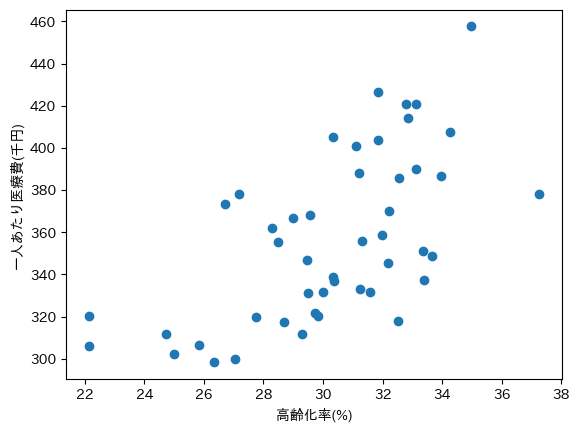

In [122]:
#散布図
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    df_merged["高齢化率(%)"],
    df_merged["一人あたり医療費(千円)"]
)

plt.xlabel("高齢化率(%)")
plt.ylabel("一人あたり医療費(千円)")

plt.show()

## 回帰分析

回帰モデルを用いて、高齢化率と医療費の関係を数値的に確認する。

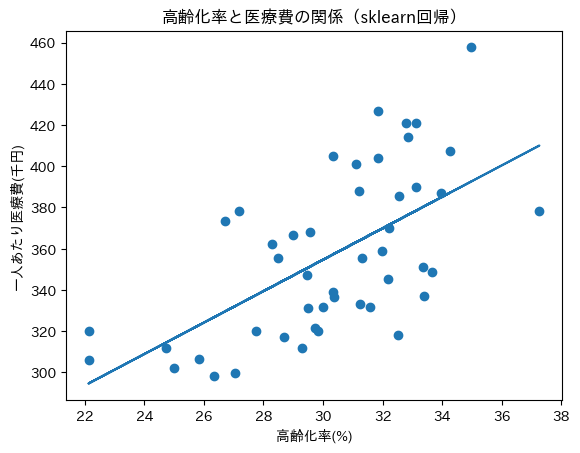

In [123]:
!pip install japanize-matplotlib

import japanize_matplotlib

#回帰直線の追加
from sklearn.linear_model import LinearRegression

X = df_merged[["高齢化率(%)"]]
y = df_merged["一人あたり医療費(千円)"]

#モデル作成
model = LinearRegression()

#学習
model.fit(X, y)

#予測
y_pred = model.predict(X)


plt.figure()

plt.scatter(X, y)
plt.plot(X, y_pred)

plt.xlabel("高齢化率(%)")
plt.ylabel("一人あたり医療費(千円)")
plt.title("高齢化率と医療費の関係（sklearn回帰）")

plt.show()

In [124]:
print('モデル関数の回帰変数 w1: %.3f' %model.coef_[0])
print('モデル関数の切片 w2: %.3f' %model.intercept_)
print('y= %.3fx + %.3f' % (model.coef_[0] , model.intercept_))
print('決定係数 R²： ', model.score(X, y))

モデル関数の回帰変数 w1: 7.624
モデル関数の切片 w2: 125.946
y= 7.624x + 125.946
決定係数 R²：  0.37972413060535726


決定係数 R² = 0.38

高齢化率によって医療費の約38%が説明されることが示された。

## 考察

本分析では、高齢化率と医療費の関係について分析をした。

相関係数 r = 0.62 となり、高齢化率が高い地域ほど医療費が高くなる傾向が確認された。  
決定係数 R² = 0.38 であったことから、高齢化率は医療費の変動の約38%を説明できることが示された。

一方で、医療費には高齢化率以外の要因も影響している可能性があり、医療機関数や所得水準などの要素を追加することで、より詳細な分析が可能になると考えられる。
また、高齢化率が全国1位である秋田県と2位である高知県の一人当たり医療費を比較すると、秋田県が378,200円、高知県が457,600円と大きく乖離している。乖離の原因を見つけることで、医療費を削減する方法が見つかる可能性がある。

なお、今回使用したデータは2020年のデータであるため、コロナウイルスが蔓延しだした最初の年であることに注意する必要がある。

## 結論

本分析では、都道府県別データを用いて高齢化率と医療費の関係を分析した。

その結果、高齢化率と医療費の間には中程度の正の相関が確認された。  
今後は複数の説明変数を用いた多変量分析を行うことで、より精度の高い分析が可能になると考えられる。

## 今後の課題

本分析では高齢化率のみを説明変数として使用したが、医療費には他の要因も影響していると考えられる。

今後は以下のような変数を追加し、多変量分析を実施することで、より詳細な要因分析を行いたい。

・医療機関数  
・平均所得  
・人口密度  
・疾病構造